In [1]:
import pandas as pd
import random

# Sample phrases per language
swahili = [
    "niko soko leo", "ninakupenda sana", "tutaonana kesho", "habari yako",
    "chakula kiko tayari", "naenda shule", "umefanya kazi", "hii ni nzuri",
    "karibu nyumbani", "tuko pamoja"
]

english = [
    "i am going home", "how are you", "this is a good day", "we will meet tomorrow",
    "the food is ready", "he is my friend", "she loves music", "this is interesting",
    "i like programming", "welcome home"
]

sheng = [
    "niko base leo", "tuko rada", "niaje bro", "hii ni poa",
    "tunaenda tao", "uko sawa msee", "wacha tuende", "hii ni noma",
    "ako na doo", "tuko pamoja sana"
]

luo = [
    "an gi tich matek", "adhiambo nitie", "wangni ber", "abiro kendo",
    "nyasaye ogwedhi", "atimoni ahinya", "wabedo maber", "idwaro chiemo",
    "gi dwaro winjo", "dhi gi kwe"
]

def generate_data(samples, label, n=100):
    data = []
    for _ in range(n):
        sentence = " ".join(random.choices(samples, k=random.randint(1,2)))
        data.append([sentence, label])
    return data

data = []
data += generate_data(swahili, "Swahili", 100)
data += generate_data(english, "English", 100)
data += generate_data(sheng, "Sheng", 100)
data += generate_data(luo, "Luo", 100)

df = pd.DataFrame(data, columns=["text", "language"])

df.to_csv("language_data.csv", index=False)

df.head()

,text,language
0,naenda shule,Swahili
1,karibu nyumbani,Swahili
2,tuko pamoja,Swahili
3,karibu nyumbani,Swahili
4,hii ni nzuri,Swahili


In [2]:
import re

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(preprocess_text)

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(2,4))
X = vectorizer.fit_transform(df['clean_text'])

y = df['language']

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

In [6]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=200)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [7]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=200)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

In [8]:
from sklearn.metrics import accuracy_score, classification_report

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Naive Bayes Accuracy: 0.9625
              precision    recall  f1-score   support

     English       1.00      1.00      1.00        18
         Luo       1.00      1.00      1.00        18
       Sheng       0.86      1.00      0.92        18
     Swahili       1.00      0.88      0.94        26

    accuracy                           0.96        80
   macro avg       0.96      0.97      0.97        80
weighted avg       0.97      0.96      0.96        80

Logistic Regression Accuracy: 0.9625
              precision    recall  f1-score   support

     English       1.00      1.00      1.00        18
         Luo       1.00      1.00      1.00        18
       Sheng       0.86      1.00      0.92        18
     Swahili       1.00      0.88      0.94        26

    accuracy                           0.96        80
   macro avg       0.96      0.97      0.97        80
weighted avg       0.97      0.96      0.96        80



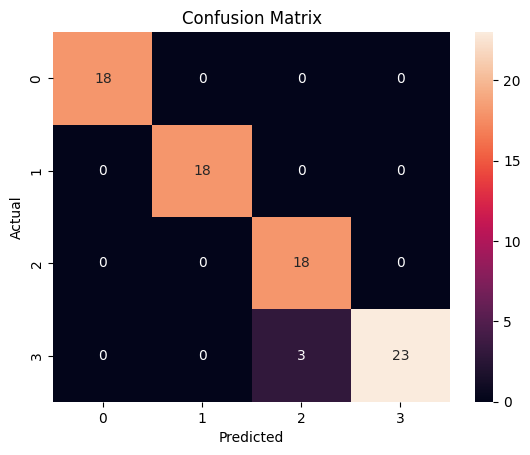

In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, lr_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [10]:
def predict_language(text):
    text = preprocess_text(text)
    vec = vectorizer.transform([text])
    return lr_model.predict(vec)[0]

print(predict_language("niko soko leo"))
print(predict_language("niaje bro"))
print(predict_language("i am going home"))

Swahili
Sheng
English


In [11]:
import pickle

# Save model
with open("model.pkl", "wb") as f:
    pickle.dump(lr_model, f)

# Save vectorizer
with open("vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

In [12]:
import random

swahili = [
"niko soko","habari yako","tunaenda shule","chakula kiko tayari",
"ninakupenda sana","tutaonana kesho","karibu nyumbani",
"hii ni nzuri","nafanya kazi","asante sana",
"naenda mjini","rafiki yangu","leo ni siku nzuri",
"tuko pamoja","umekula","pole sana","hii ni tamu",
"nafurahi kukuona","nitakuja kesho","sijui vizuri"
]

english = [
"i am going home","how are you","this is a good day",
"we will meet tomorrow","the food is ready",
"he is my friend","she loves music","this is interesting",
"i like programming","welcome home",
"today is a great day","i am learning python",
"let us go outside","this is amazing","i feel happy",
"can you help me","see you later","good morning",
"have a nice day","i enjoy coding"
]

sheng = [
"niaje bro","uko aje","tuko base","hii ni poa",
"tunaenda tao","uko rada","ako na doo",
"wacha tuende","hii ni noma","tuko pamoja sana",
"sasa buda","umechill","hapa ni kazi",
"manze hii ni kali","uko sawa msee",
"tunachapa story","hii ni legit","tuko fresh",
"niko fiti","hii ni design gani"
]

luo = [
"an gi tich matek","adhiambo nitie","wangni ber",
"abiro kendo","nyasaye ogwedhi","atimoni ahinya",
"wabedo maber","idwaro chiemo","gi dwaro winjo",
"dhi gi kwe","ber ahinya","an bende abiro",
"chiemo ber","ngima ber","nyithindo maber",
"in gi kwe","abiro sani","ber matek",
"nyasaye ber","kendo ibiro"
]

def make_lines(phrases, label):
    lines = []
    for _ in range(500):
        sentence = " ".join(random.choices(phrases, k=random.randint(2,4)))
        lines.append(f"{sentence},{label}")
    return lines

lines = ["text,language"]
lines += make_lines(swahili, "Swahili")
lines += make_lines(english, "English")
lines += make_lines(sheng, "Sheng")
lines += make_lines(luo, "Luo")

# PRINT EVERYTHING
for line in lines:
    print(line)

text,language
nafanya kazi habari yako,Swahili
nafurahi kukuona karibu nyumbani hii ni tamu,Swahili
hii ni tamu nitakuja kesho karibu nyumbani hii ni nzuri,Swahili
ninakupenda sana tunaenda shule naenda mjini tutaonana kesho,Swahili
nafurahi kukuona ninakupenda sana,Swahili
umekula nafanya kazi,Swahili
ninakupenda sana umekula,Swahili
nafurahi kukuona karibu nyumbani,Swahili
tuko pamoja rafiki yangu sijui vizuri,Swahili
niko soko tuko pamoja nitakuja kesho tutaonana kesho,Swahili
ninakupenda sana umekula leo ni siku nzuri,Swahili
leo ni siku nzuri ninakupenda sana,Swahili
tutaonana kesho nafurahi kukuona pole sana ninakupenda sana,Swahili
rafiki yangu ninakupenda sana pole sana hii ni tamu,Swahili
tunaenda shule niko soko sijui vizuri,Swahili
nitakuja kesho naenda mjini,Swahili
naenda mjini tutaonana kesho niko soko ninakupenda sana,Swahili
leo ni siku nzuri nafanya kazi,Swahili
habari yako leo ni siku nzuri,Swahili
sijui vizuri nafurahi kukuona nafurahi kukuona nafanya kazi,Swahili
hi